23:36:33 - cmdstanpy - INFO - Chain [1] start processing
23:36:36 - cmdstanpy - INFO - Chain [1] done processing
23:36:37 - cmdstanpy - INFO - Chain [1] start processing
23:36:40 - cmdstanpy - INFO - Chain [1] done processing
23:36:41 - cmdstanpy - INFO - Chain [1] start processing
23:36:43 - cmdstanpy - INFO - Chain [1] done processing
23:36:44 - cmdstanpy - INFO - Chain [1] start processing
23:36:47 - cmdstanpy - INFO - Chain [1] done processing
23:36:48 - cmdstanpy - INFO - Chain [1] start processing
23:36:51 - cmdstanpy - INFO - Chain [1] done processing
23:36:51 - cmdstanpy - INFO - Chain [1] start processing
23:36:54 - cmdstanpy - INFO - Chain [1] done processing
23:36:55 - cmdstanpy - INFO - Chain [1] start processing
23:36:58 - cmdstanpy - INFO - Chain [1] done processing
23:36:59 - cmdstanpy - INFO - Chain [1] start processing
23:37:02 - cmdstanpy - INFO - Chain [1] done processing


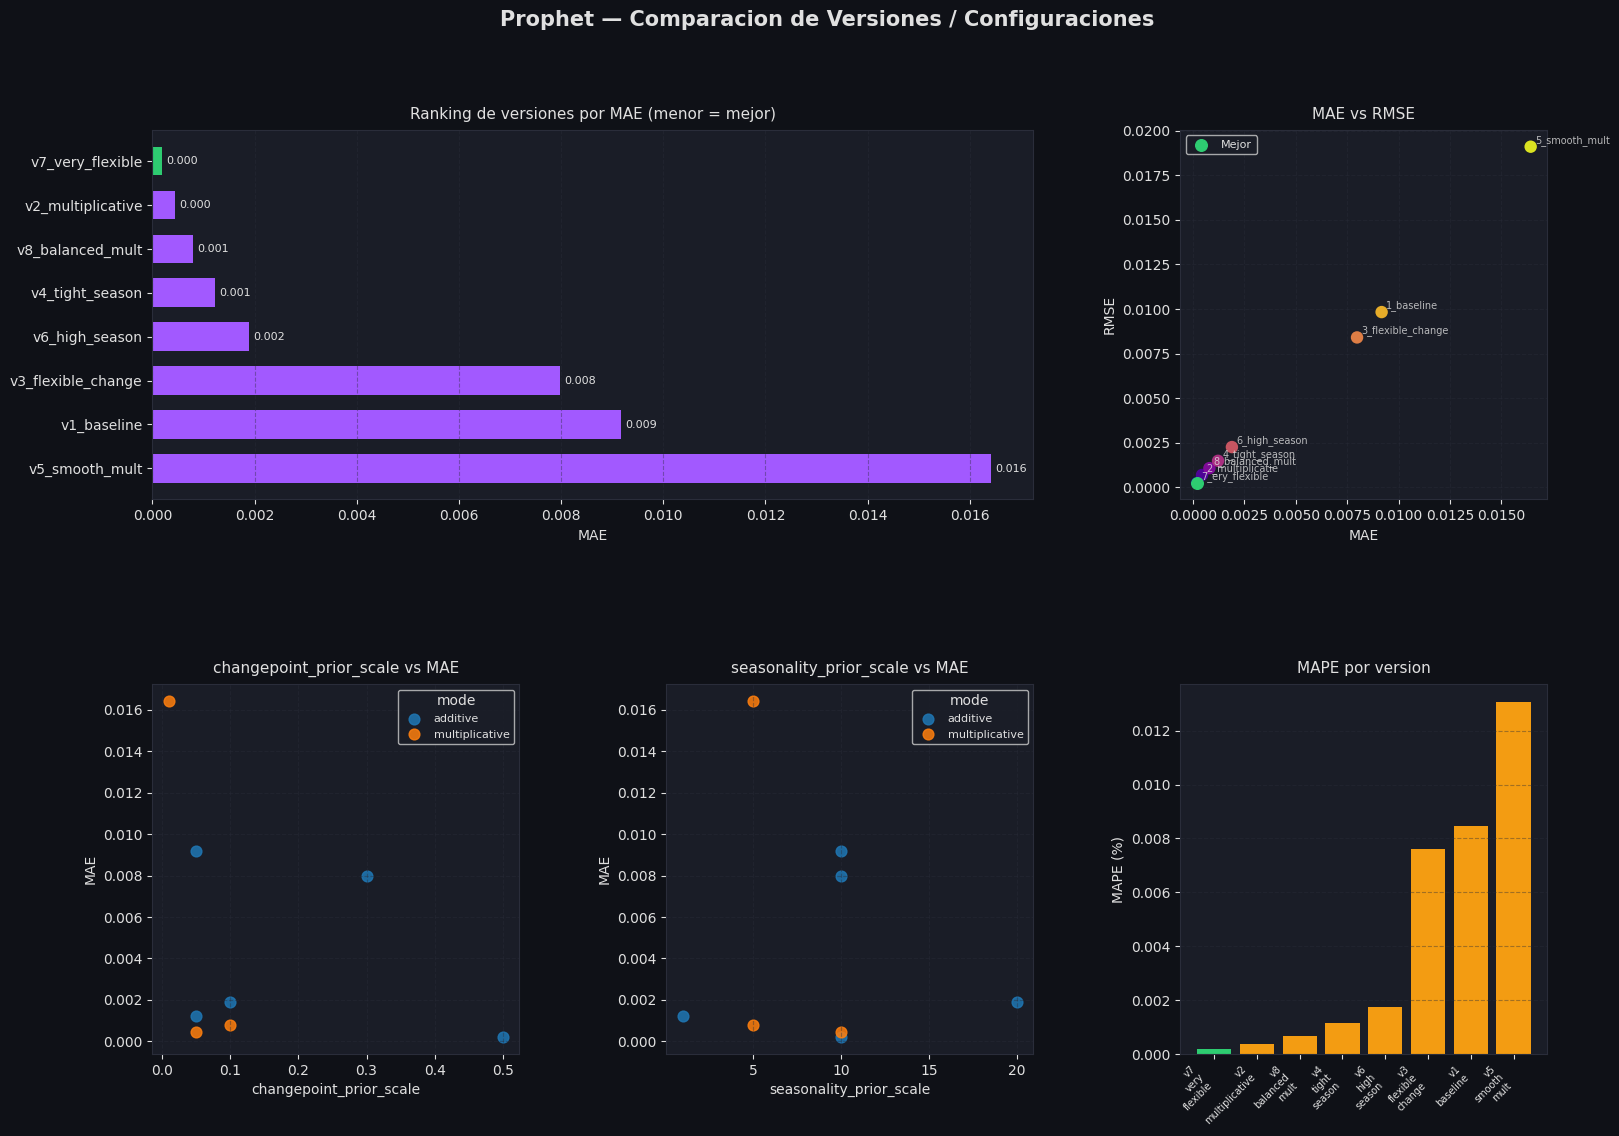

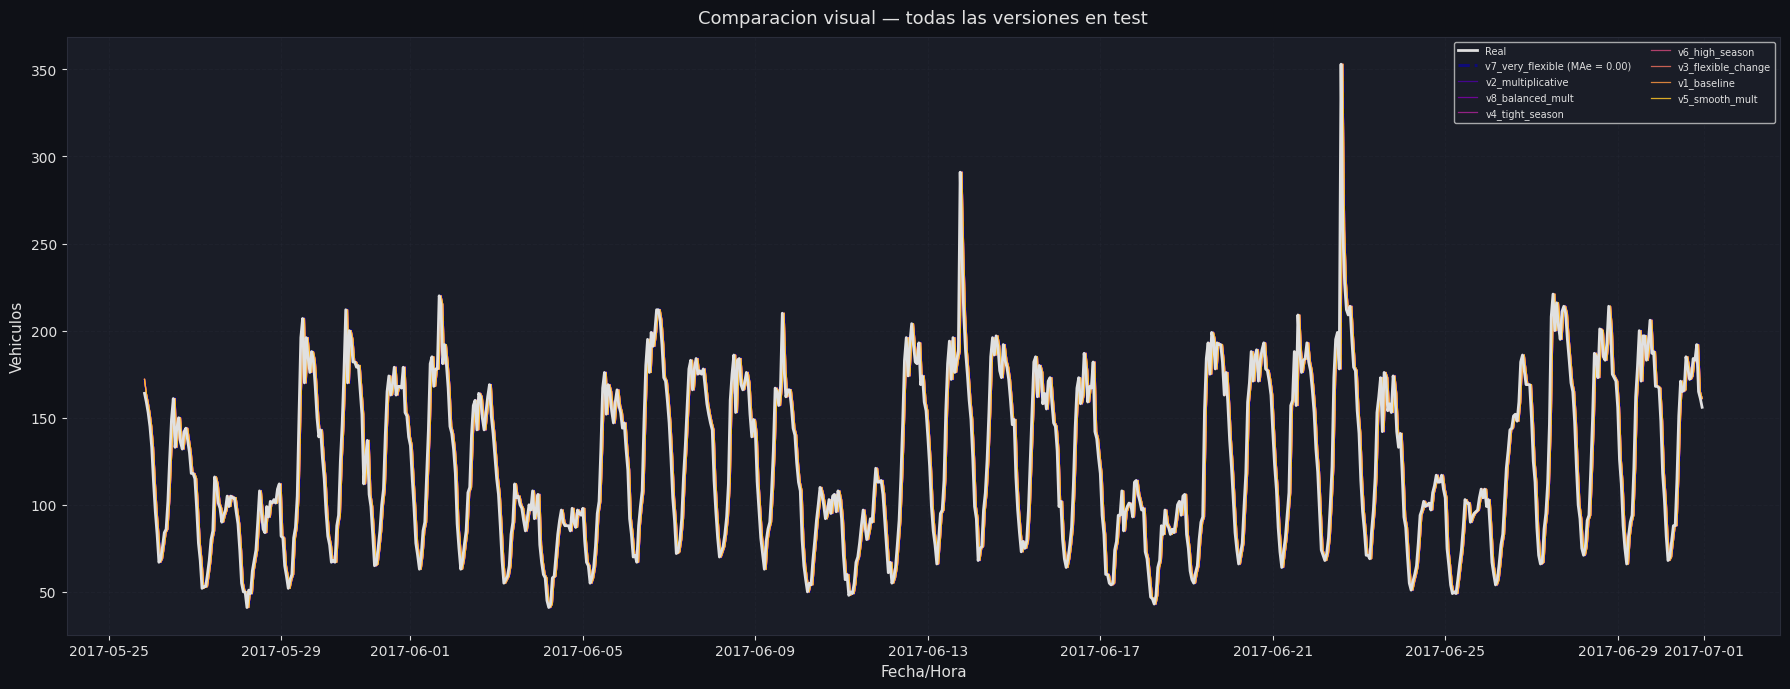

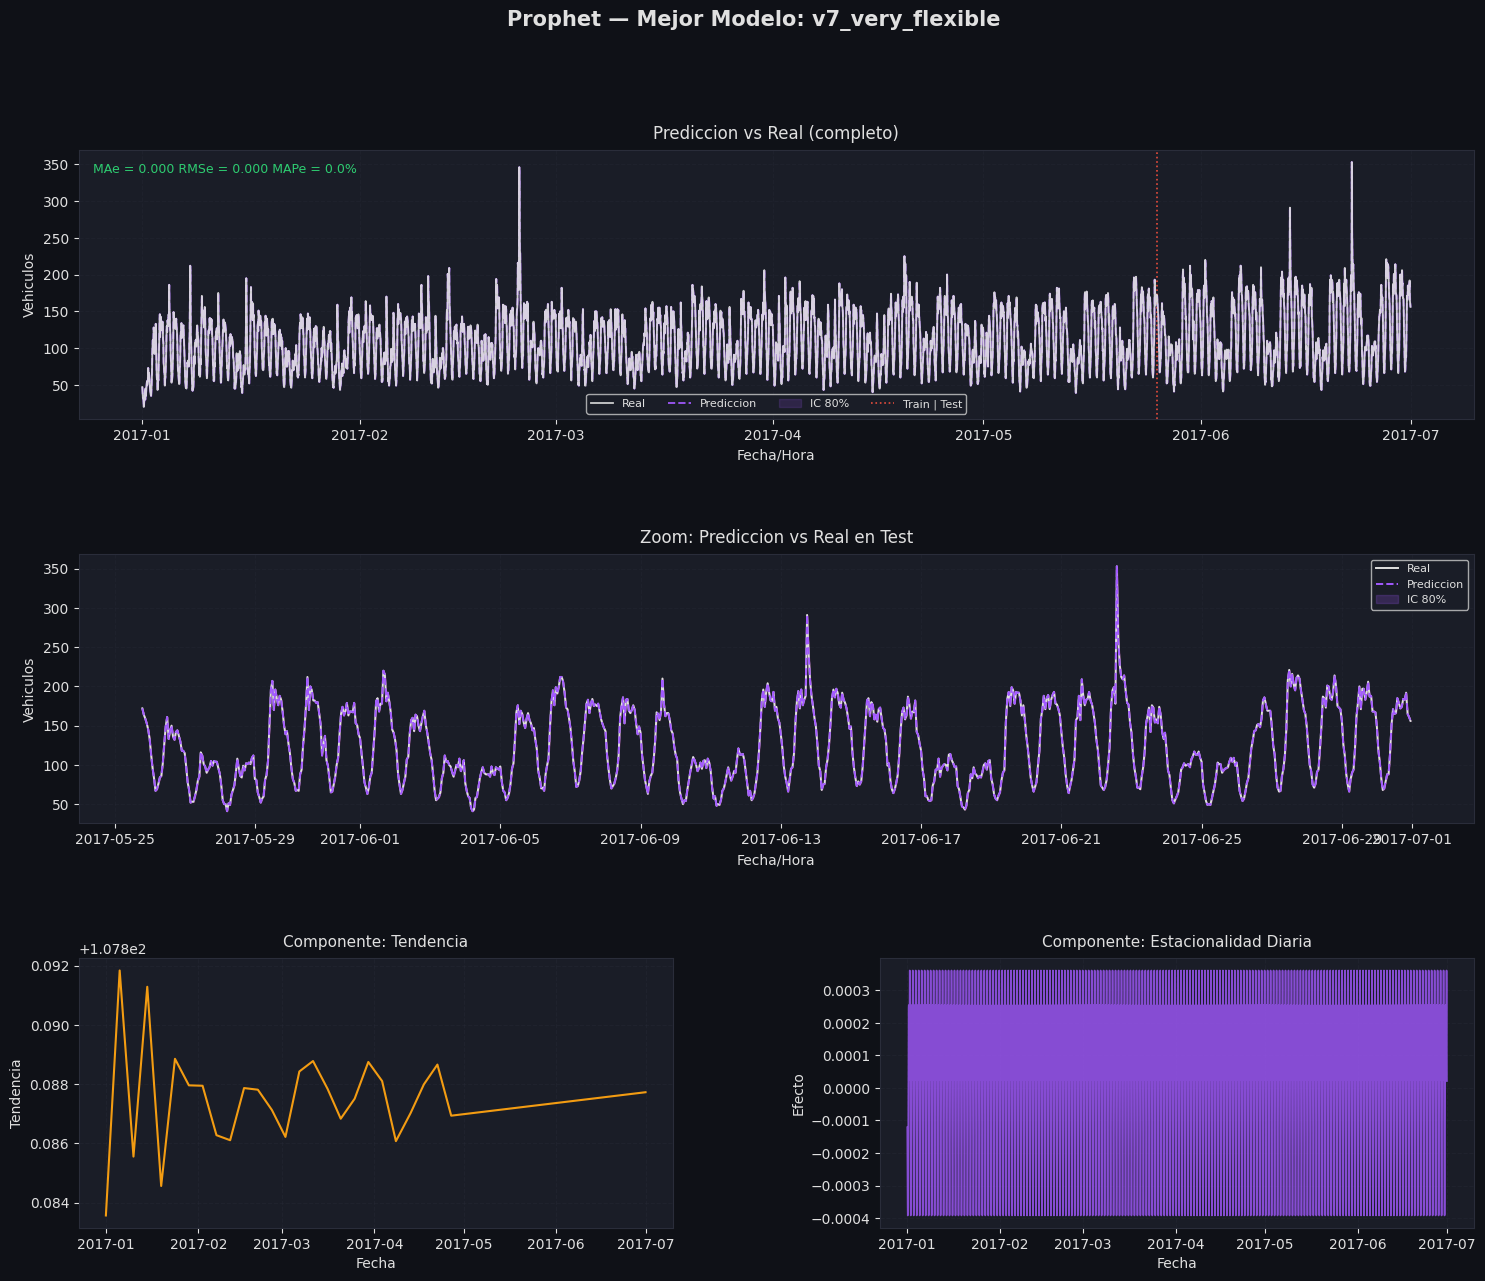

23:37:04 - cmdstanpy - INFO - Chain [1] start processing
23:37:06 - cmdstanpy - INFO - Chain [1] done processing
23:37:08 - cmdstanpy - INFO - Chain [1] start processing
23:37:09 - cmdstanpy - INFO - Chain [1] done processing
23:37:11 - cmdstanpy - INFO - Chain [1] start processing
23:37:14 - cmdstanpy - INFO - Chain [1] done processing
23:37:16 - cmdstanpy - INFO - Chain [1] start processing
23:37:17 - cmdstanpy - INFO - Chain [1] done processing
23:37:19 - cmdstanpy - INFO - Chain [1] start processing
23:37:20 - cmdstanpy - INFO - Chain [1] done processing
23:37:22 - cmdstanpy - INFO - Chain [1] start processing
23:37:24 - cmdstanpy - INFO - Chain [1] done processing
23:37:26 - cmdstanpy - INFO - Chain [1] start processing
23:37:28 - cmdstanpy - INFO - Chain [1] done processing
23:37:30 - cmdstanpy - INFO - Chain [1] start processing
23:37:32 - cmdstanpy - INFO - Chain [1] done processing
23:37:34 - cmdstanpy - INFO - Chain [1] start processing
23:37:36 - cmdstanpy - INFO - Chain [1]

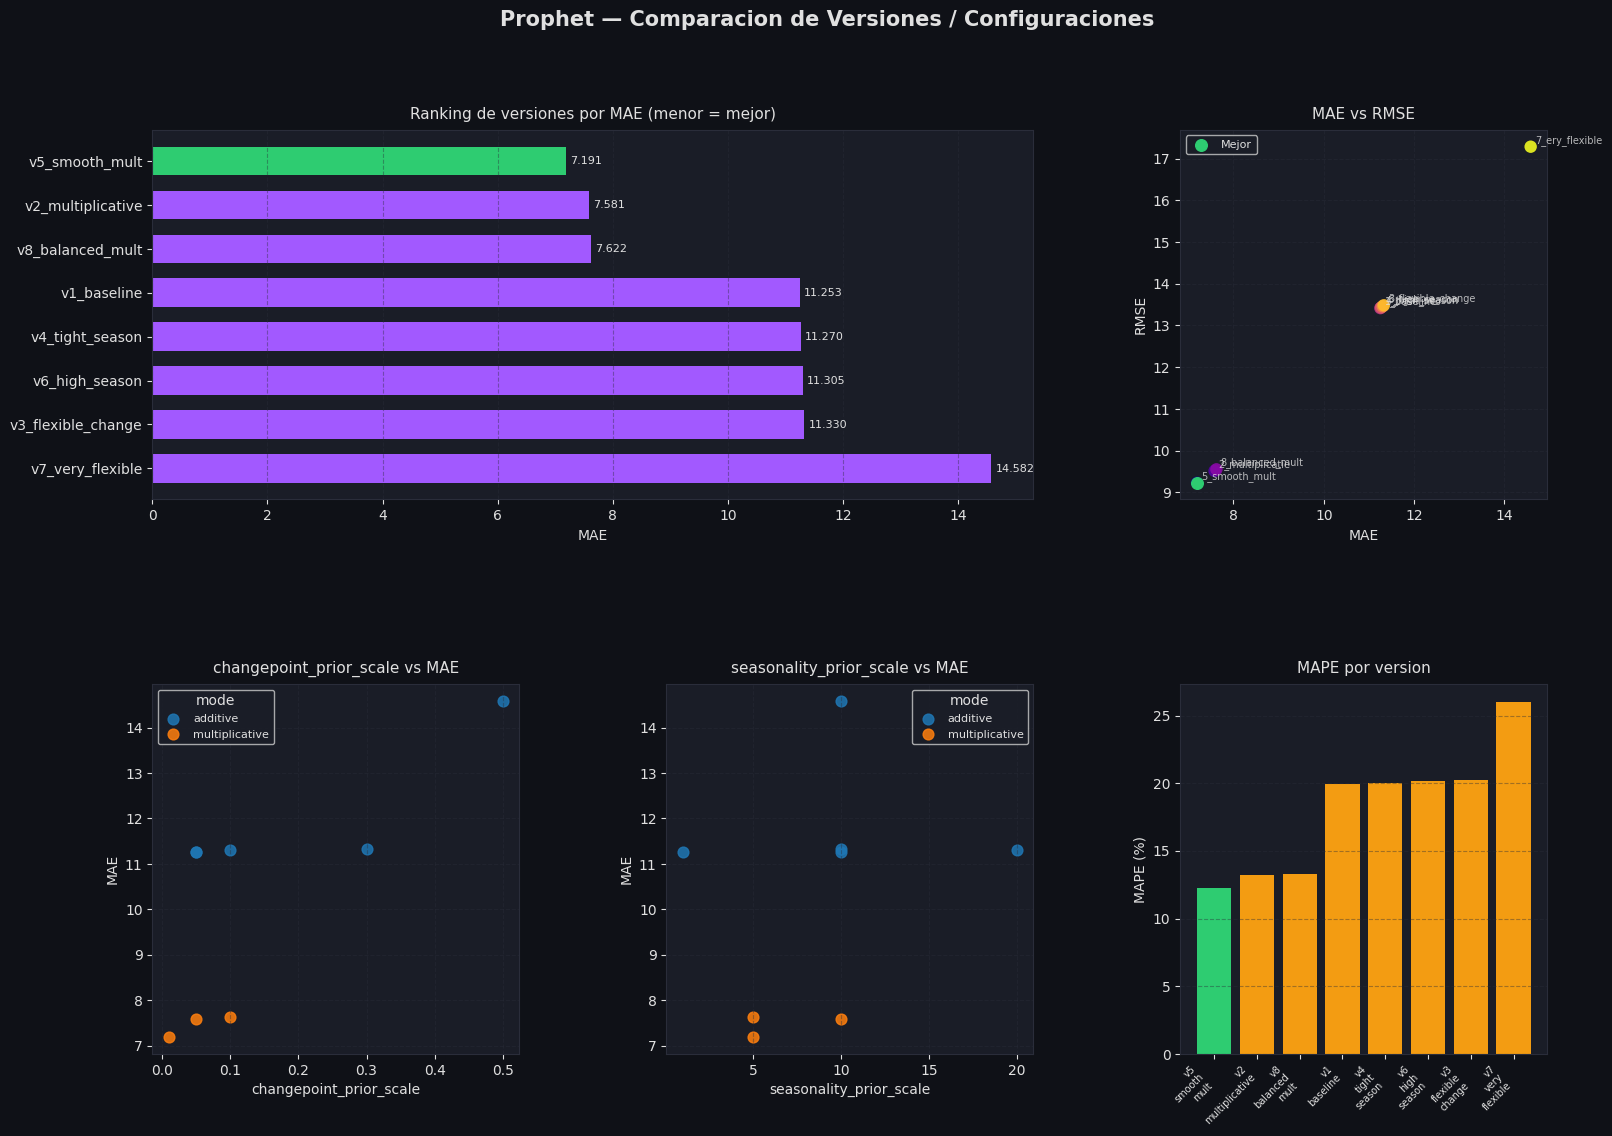

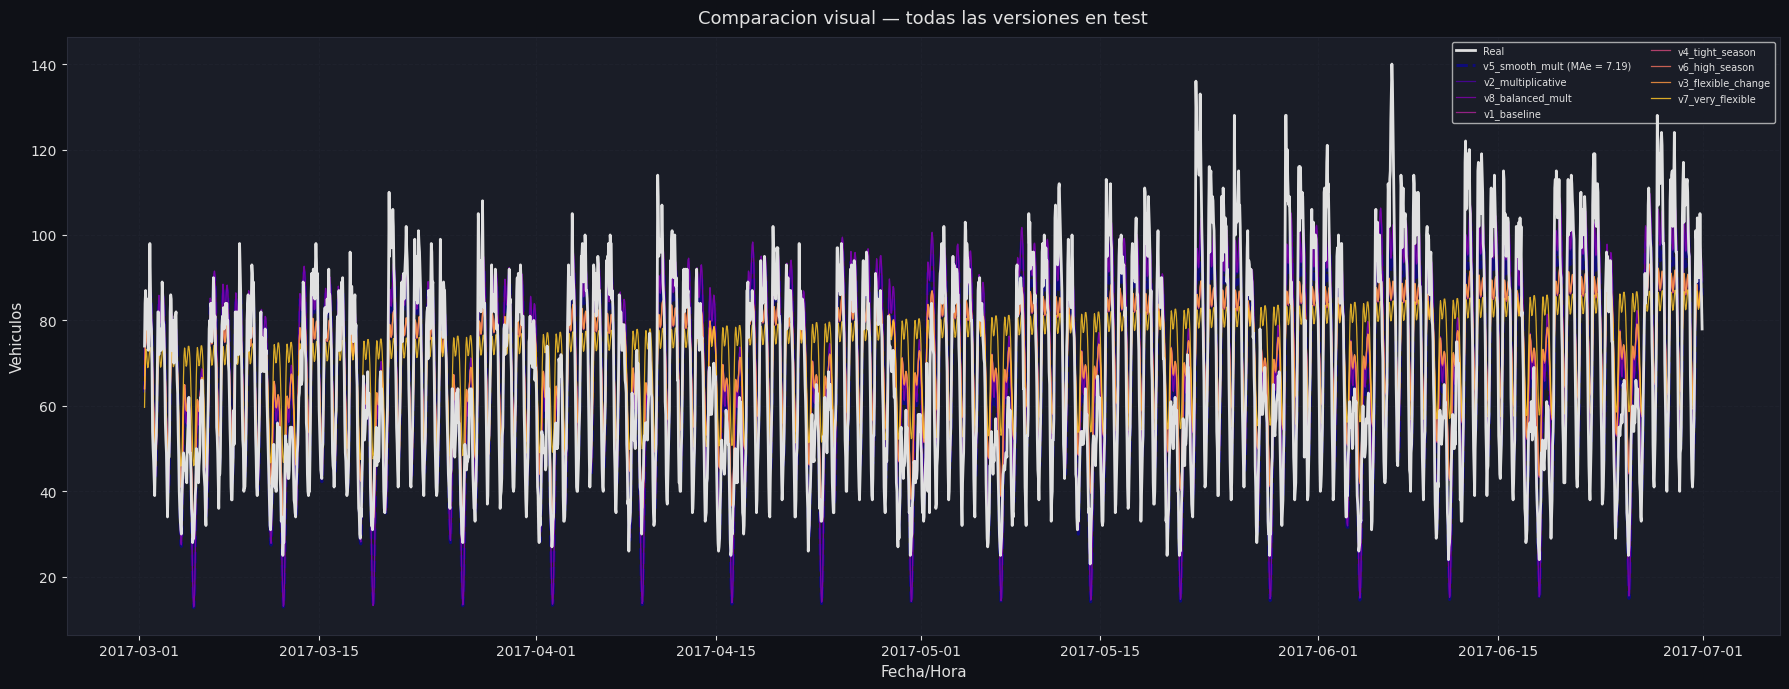

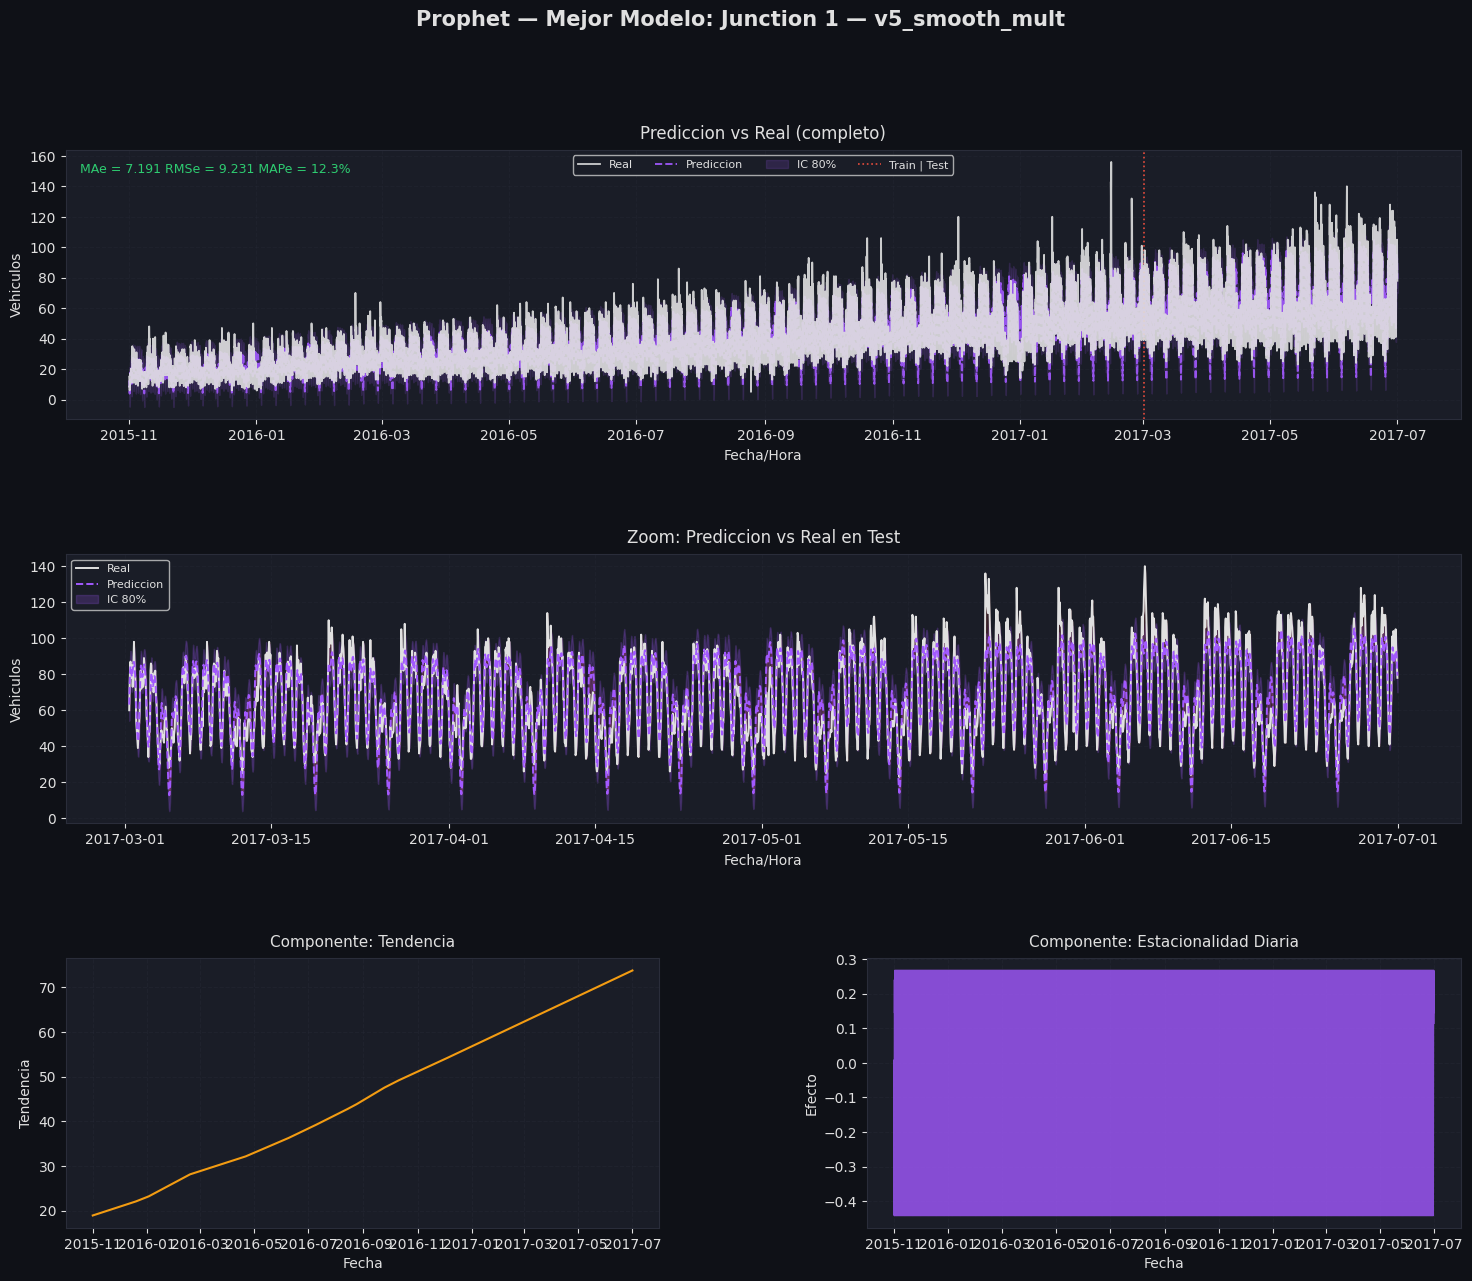

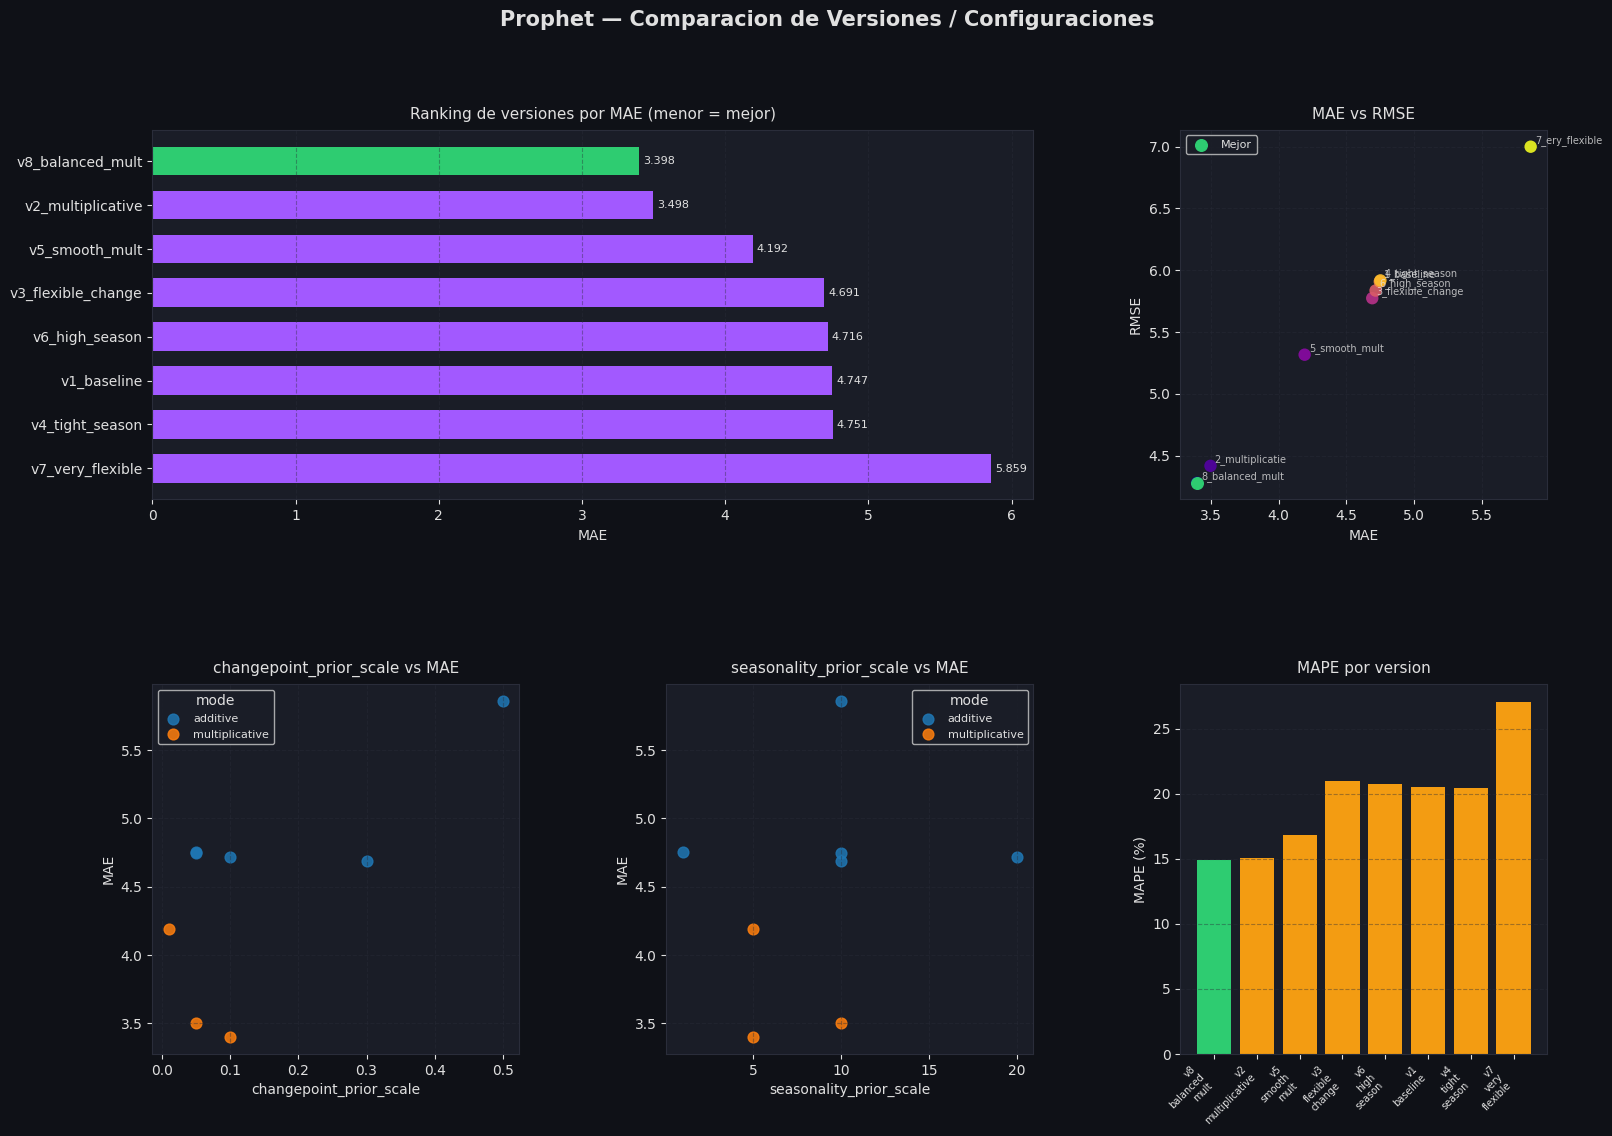

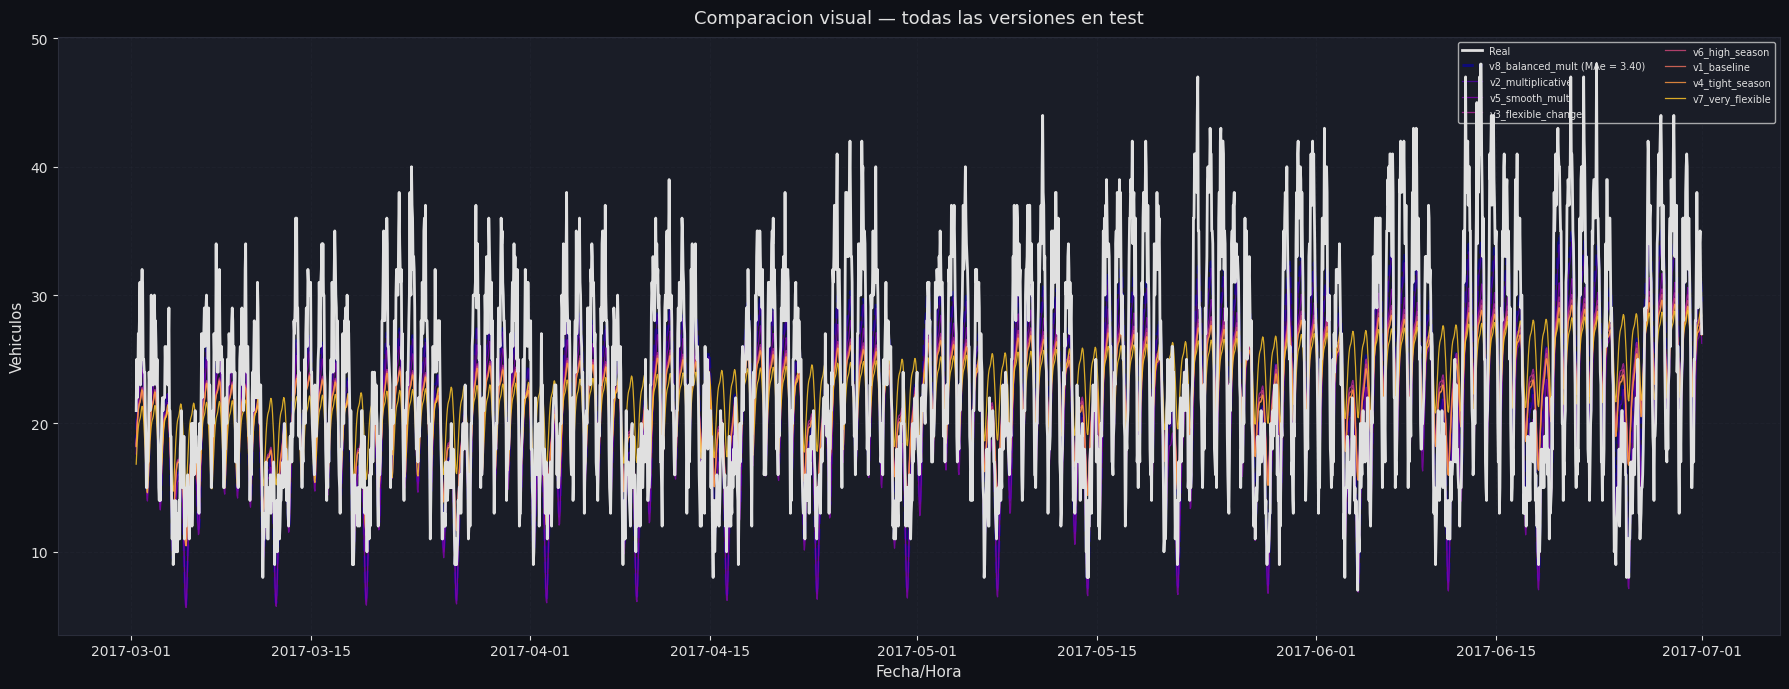

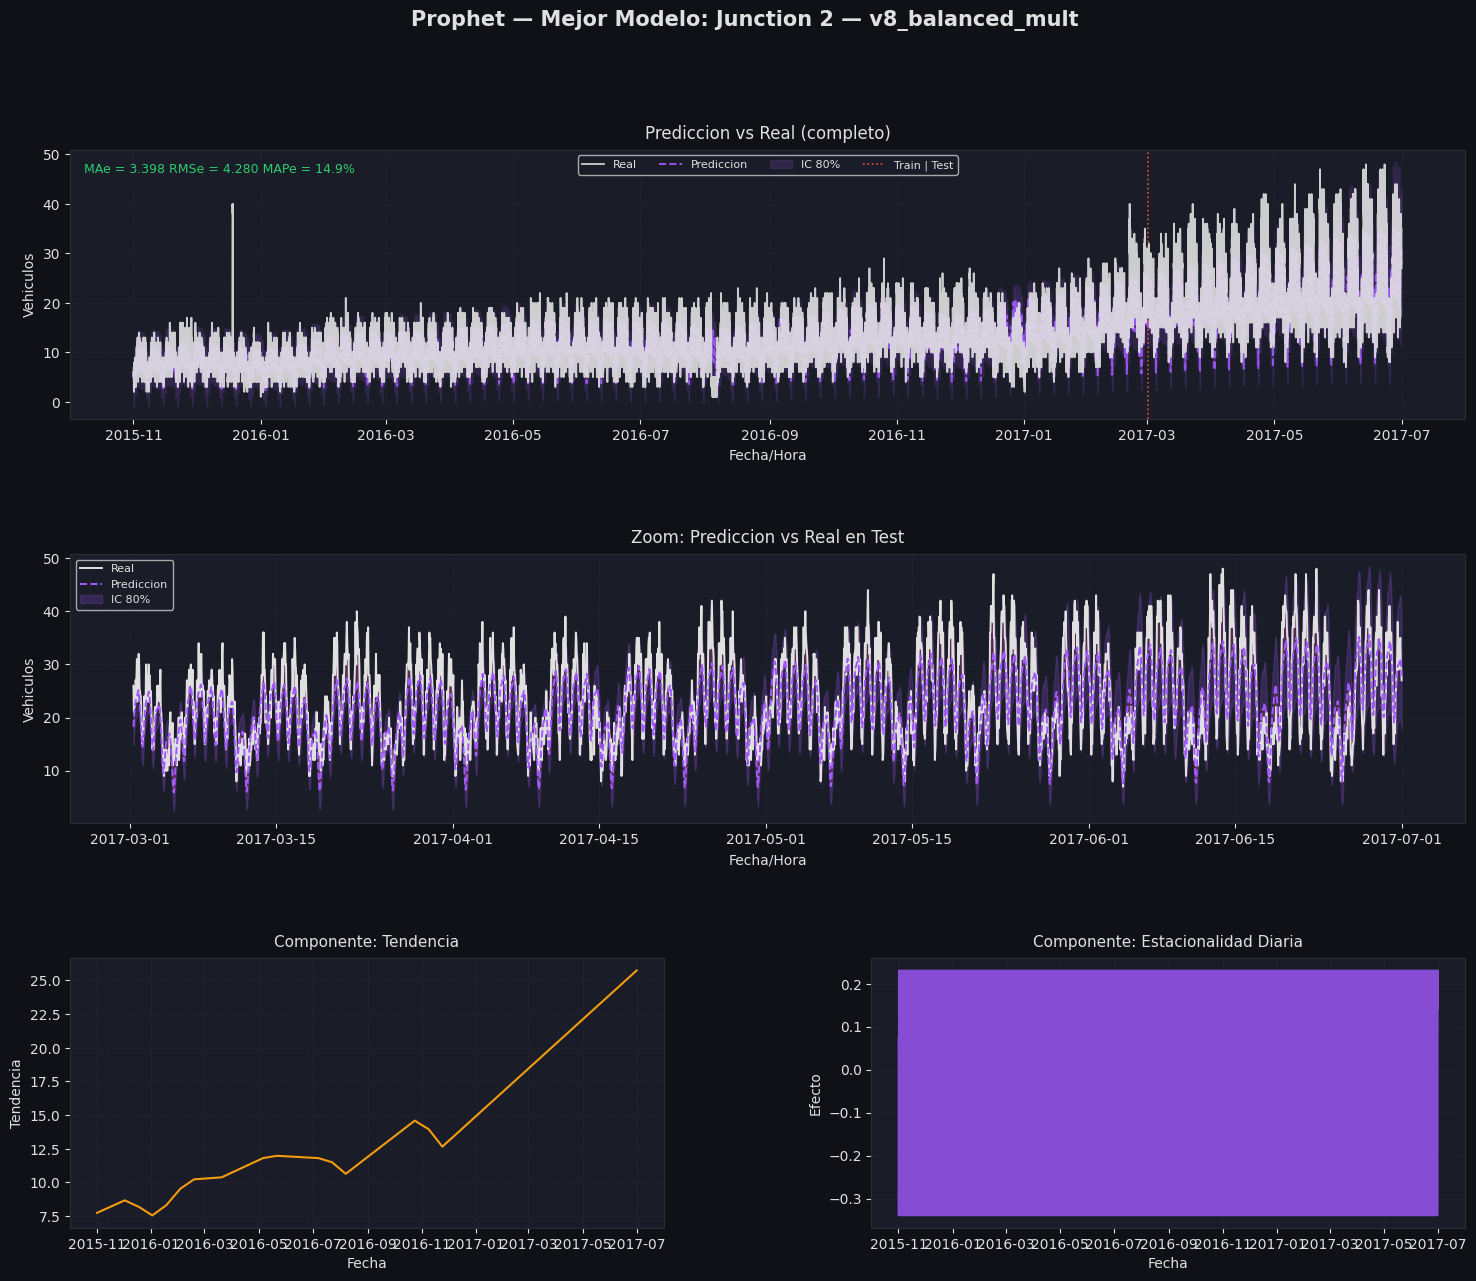

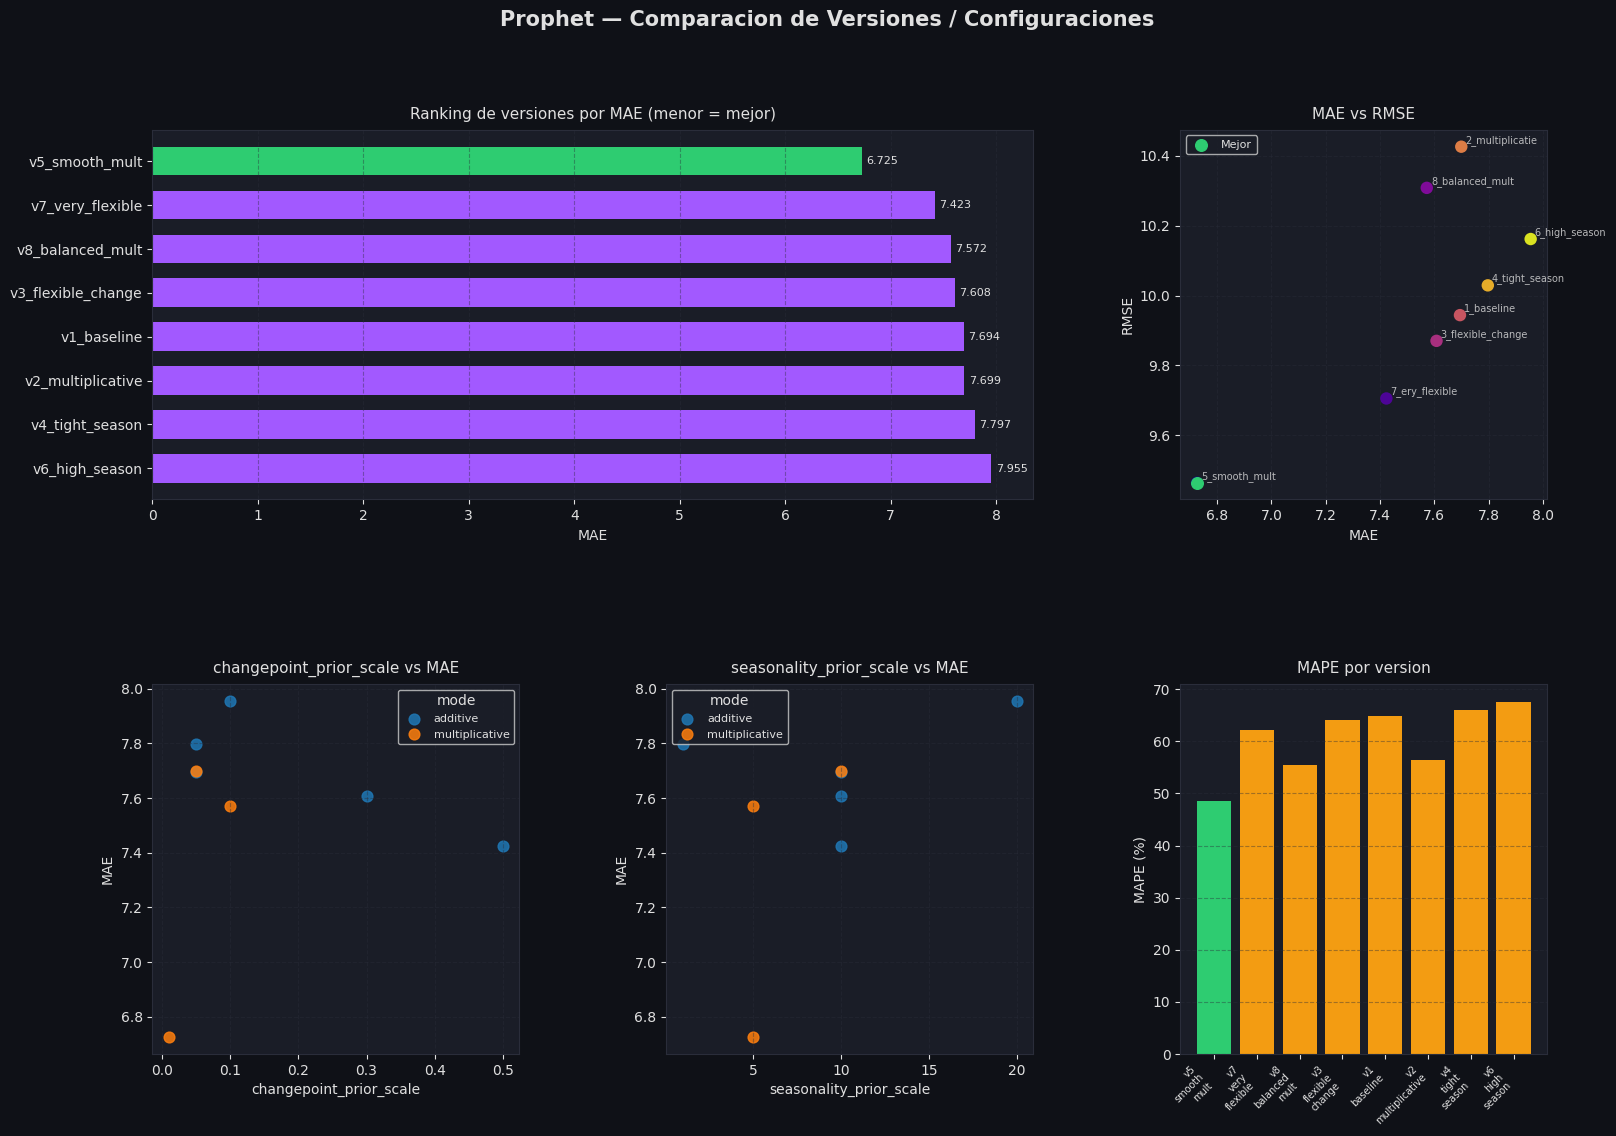

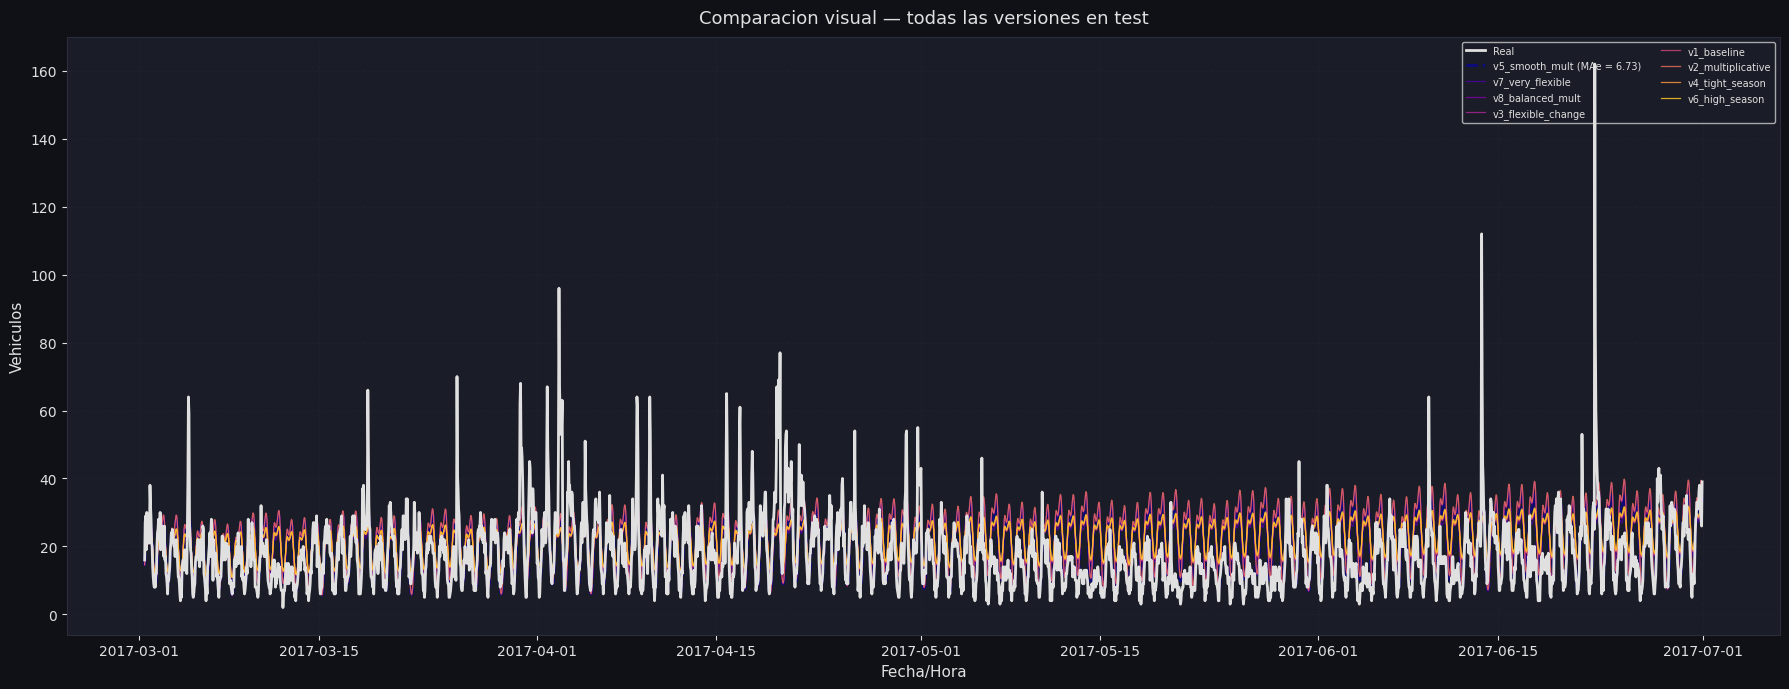

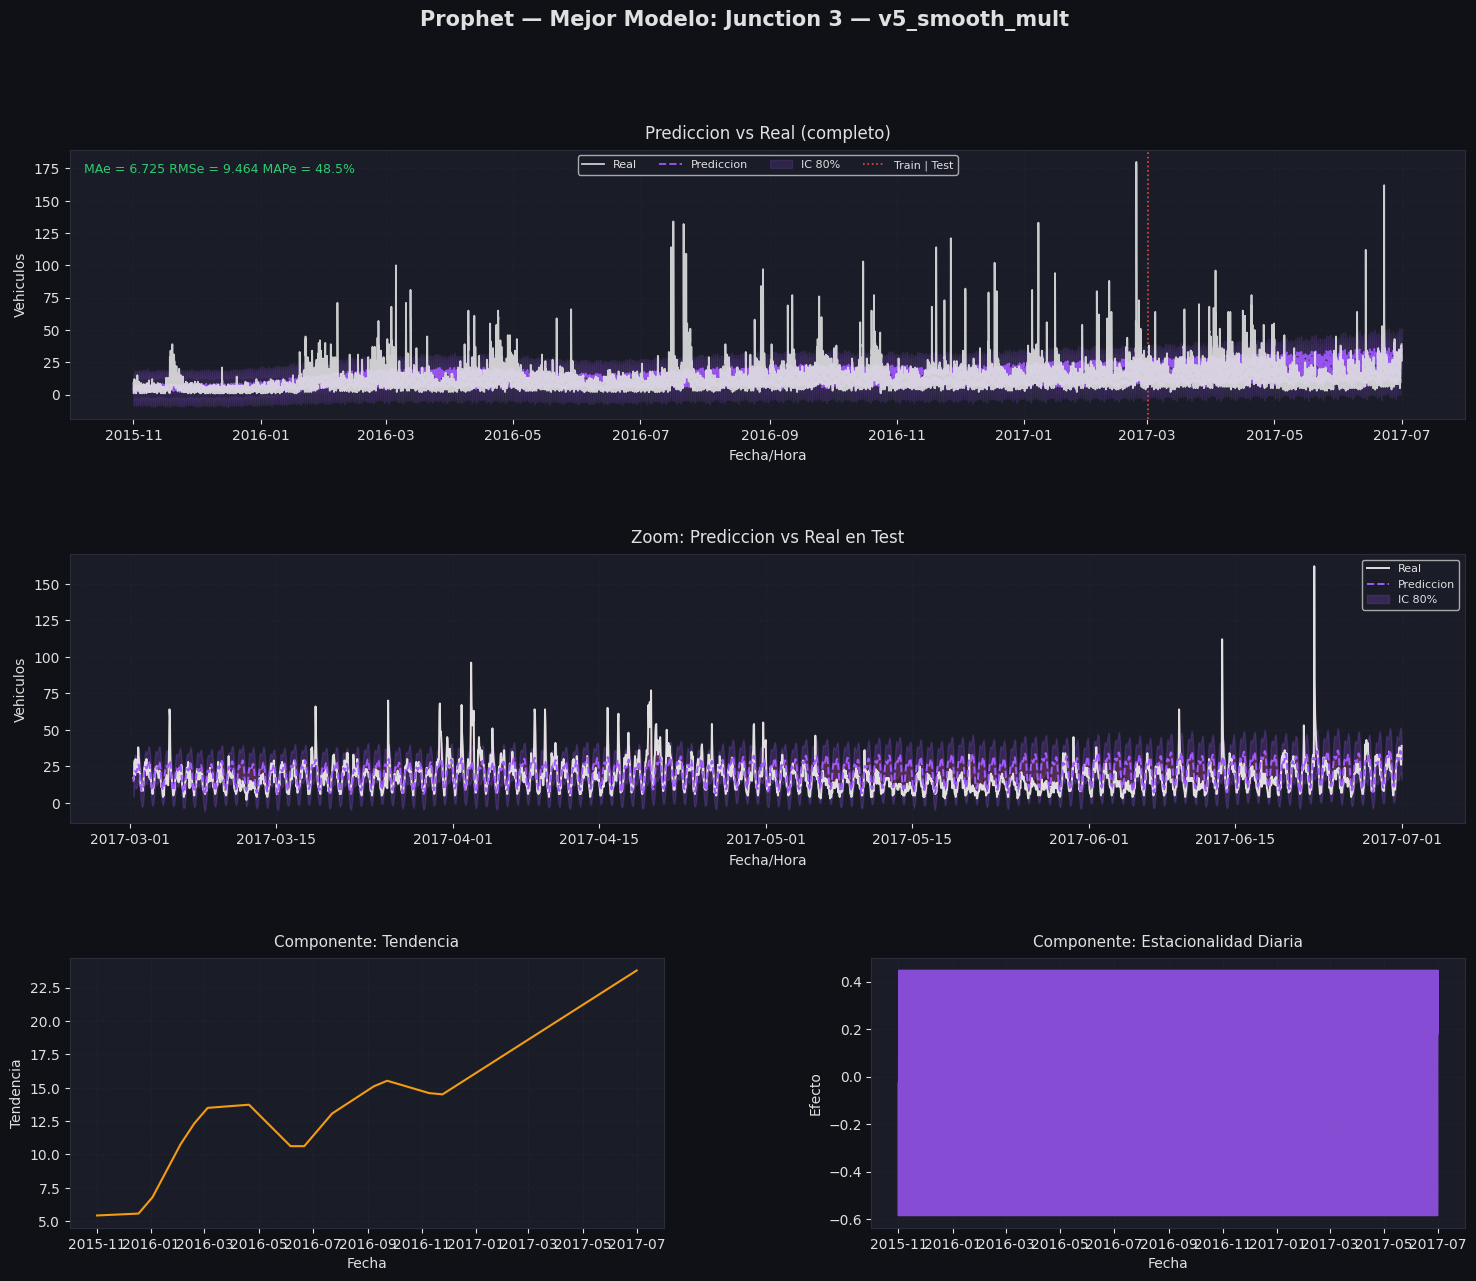

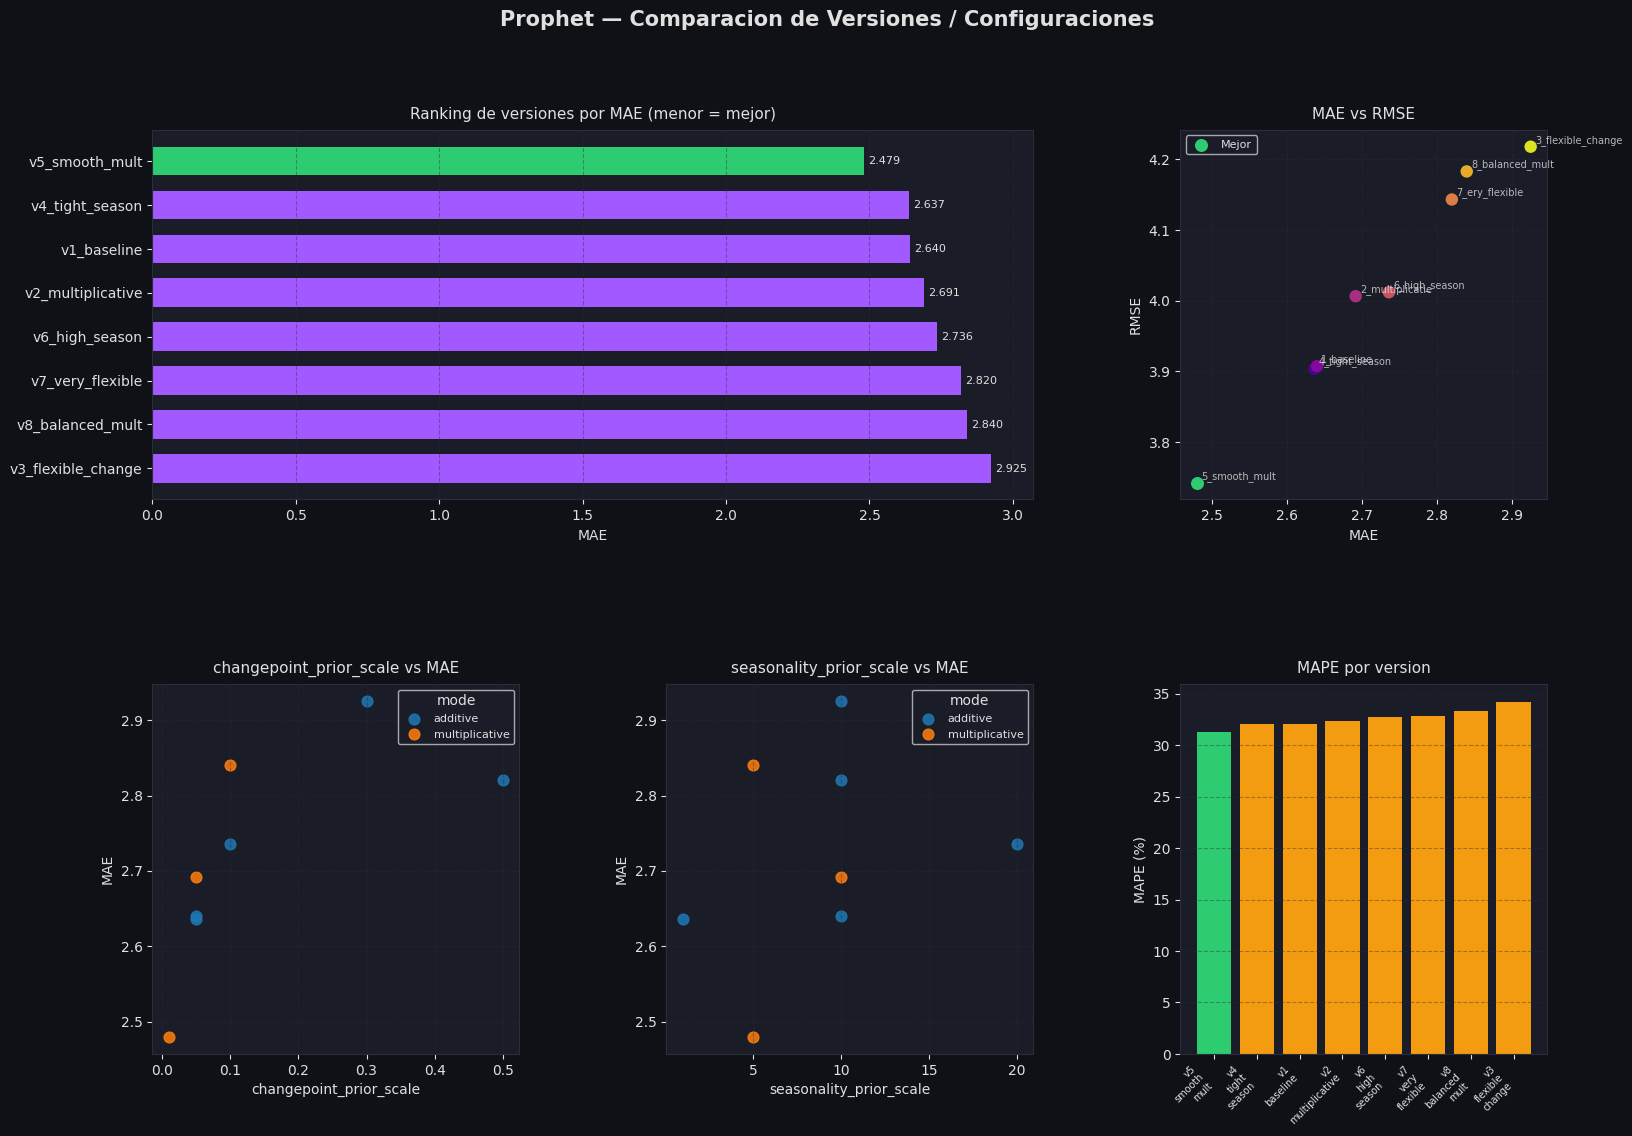

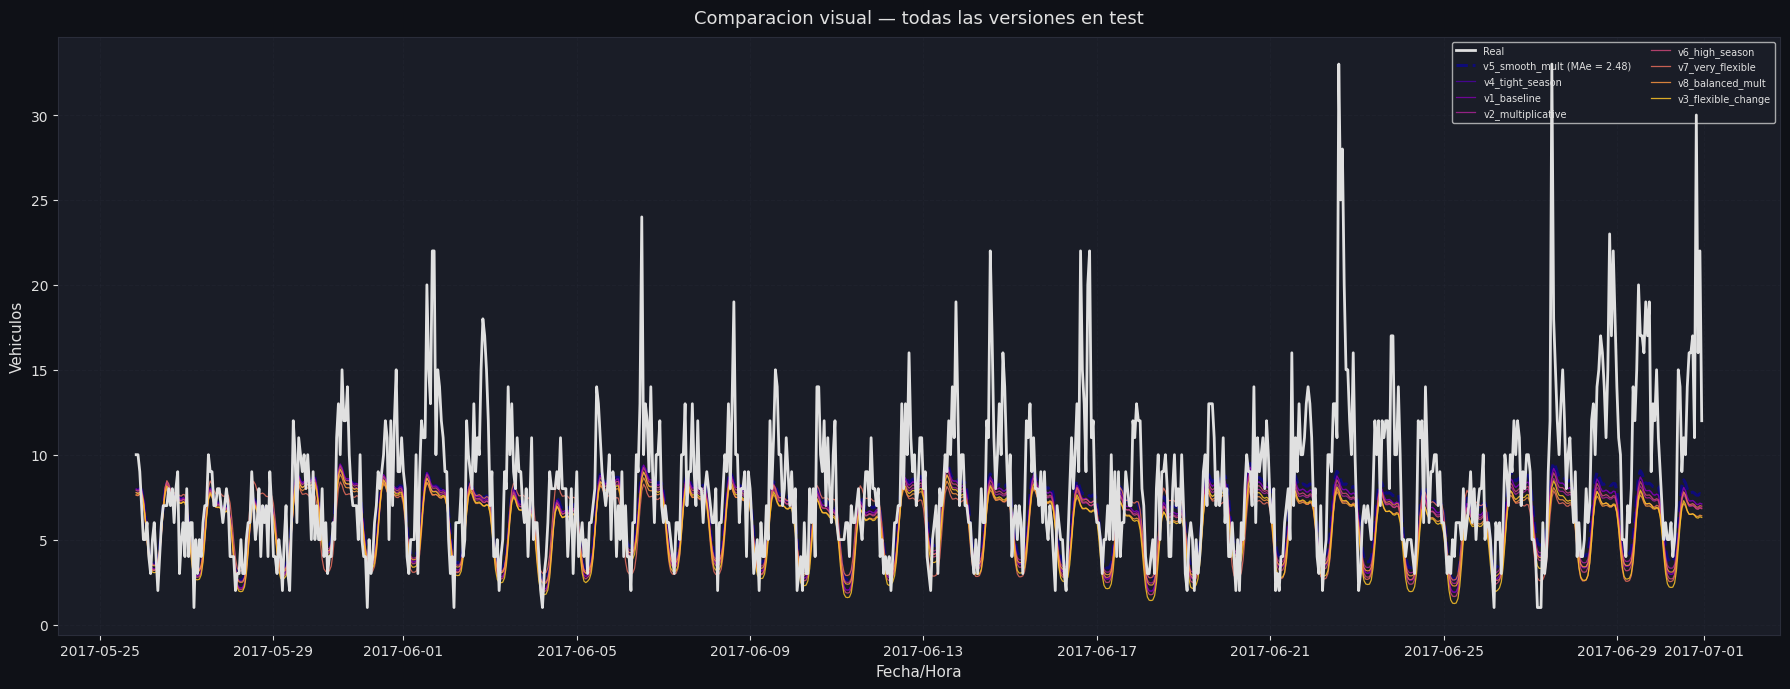

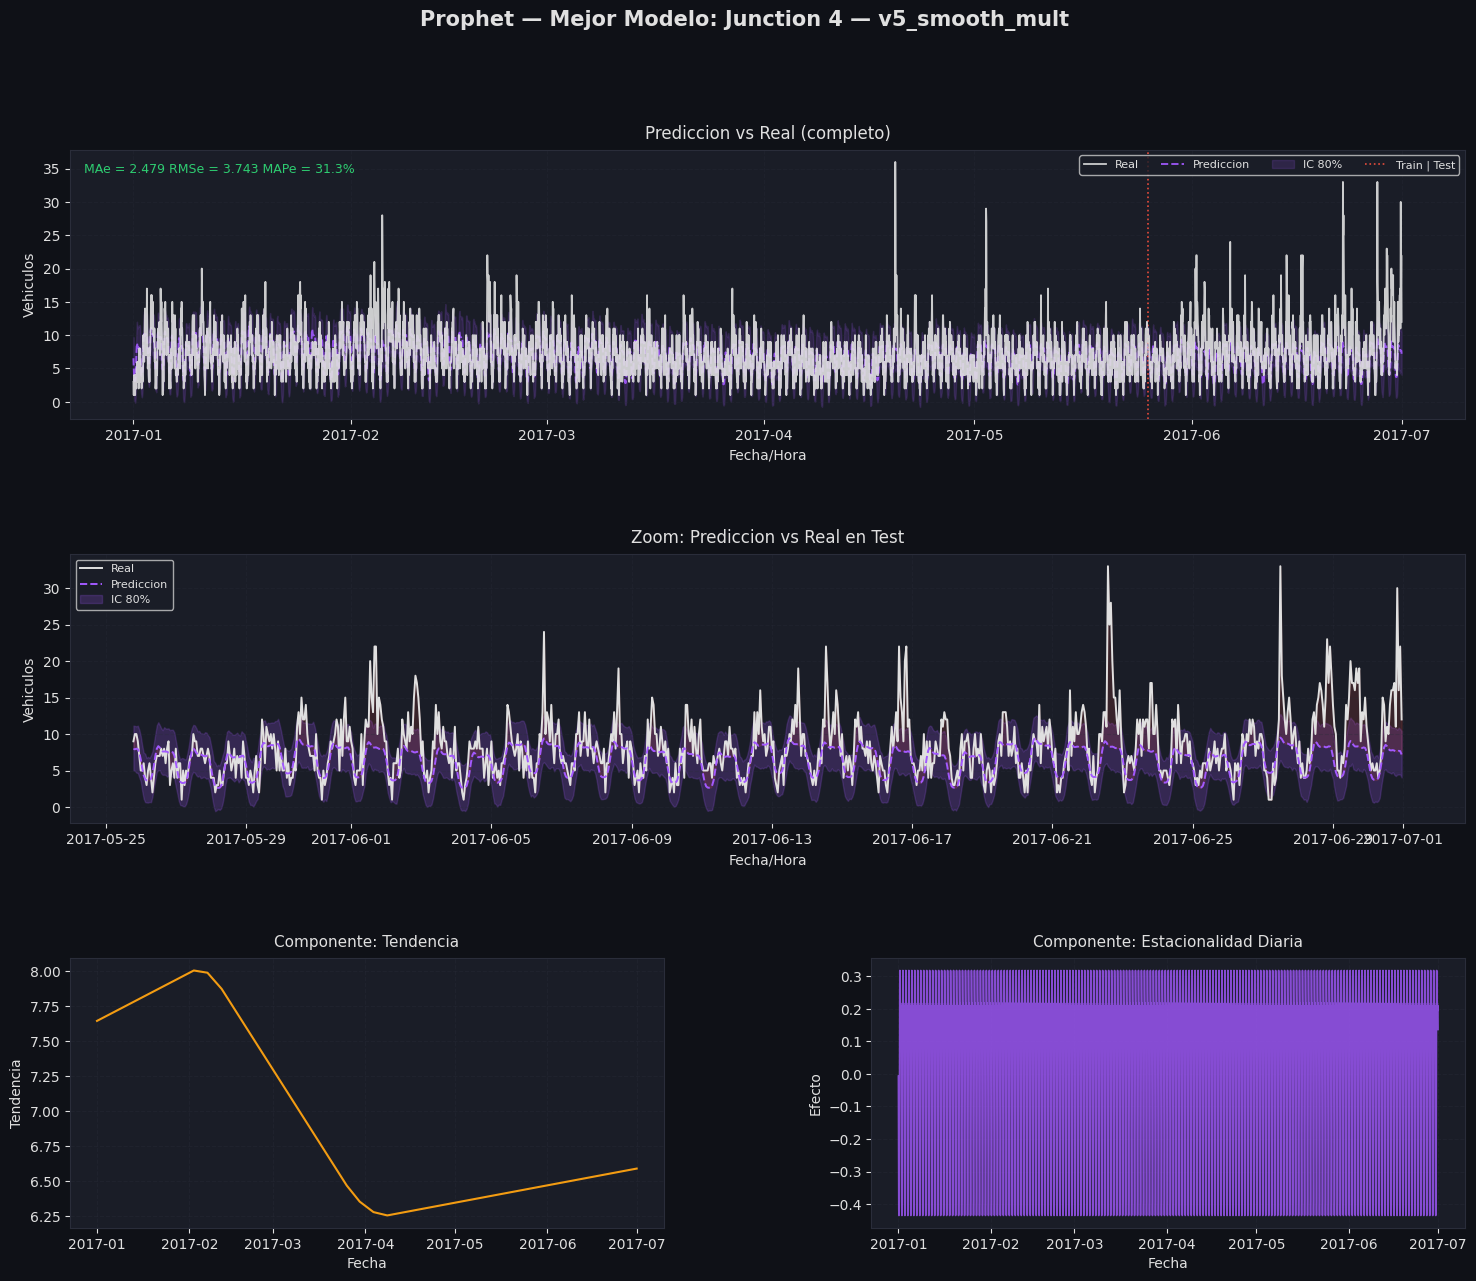

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from matplotlib import pyplot as plt
from matplotlib import gridspec

import pandas as pd
import numpy as np

PROPHET_CONFIGS = { 
    'v1_baseline': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10,
        'seasonality_mode':        'additive',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
    'v2_multiplicative': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10,
        'seasonality_mode':        'multiplicative',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
    'v3_flexible_change': {
        'changepoint_prior_scale': 0.3,
        'seasonality_prior_scale': 10,
        'seasonality_mode':        'additive',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
    'v4_tight_season': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 1,
        'seasonality_mode':        'additive',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
    'v5_smooth_mult': {
        'changepoint_prior_scale': 0.01,
        'seasonality_prior_scale': 5,
        'seasonality_mode':        'multiplicative',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
    'v6_high_season': {
        'changepoint_prior_scale': 0.1,
        'seasonality_prior_scale': 20,
        'seasonality_mode':        'additive',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
    'v7_very_flexible': {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 10,
        'seasonality_mode':        'additive',
        'daily_seasonality':       True,
        'weekly_seasonality':      False,
        'yearly_seasonality':      False,
    },
    'v8_balanced_mult': {
        'changepoint_prior_scale': 0.1,
        'seasonality_prior_scale': 5,
        'seasonality_mode':        'multiplicative',
        'daily_seasonality':       True,
        'weekly_seasonality':      True,
        'yearly_seasonality':      False,
    },
}

def preparar_datos(filepath):
    dataFrame = pd.read_csv(filepath)
    dataFrame['DateTime'] = pd.to_datetime(dataFrame['DateTime'])
    dataFrame = dataFrame.sort_values('DateTime').reset_index(drop = True)

    pivot = dataFrame.pivot_table(index = 'DateTime', columns = 'Junction', values = 'Vehicles', aggfunc = 'sum')
    pivot.columns = [f'junction_{c}' for c in pivot.columns]
    pivot = pivot.reset_index()

    junction_cols = [c for c in pivot.columns if c.startswith('junction_')]

    pivot['y'] = pivot[junction_cols].sum(axis = 1)
    pivot = pivot.rename(columns = {'DateTime': 'ds'})

    junction_dummies = pd.get_dummies(dataFrame['Junction'], prefix = 'junction', drop_first = False).astype(float)
    junction_cols = junction_dummies.columns.tolist()

    df = pivot[['ds', 'y'] + junction_cols].dropna().reset_index(drop = True)
    return df, junction_cols

def entrenar_evaluar_prophet(df, config, junction_cols, test_frac = 0.2):
    split_idx = int(len(df) * (1 - test_frac))
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
 
    m = Prophet(
        changepoint_prior_scale = config['changepoint_prior_scale'],
        seasonality_prior_scale = config['seasonality_prior_scale'],
        seasonality_mode = config['seasonality_mode'],
        daily_seasonality = config['daily_seasonality'],
        weekly_seasonality = config['weekly_seasonality'],
        yearly_seasonality = config['yearly_seasonality'],
    )

    for col in junction_cols: m.add_regressor(col)
 
    m.fit(train_df)
 
    future = m.make_future_dataframe(periods = len(test_df), freq = 'h')
    for col in junction_cols: future[col] = df[col].values[:len(future)]

    forecast = m.predict(future)

    test_preds = forecast.iloc[split_idx:]['yhat'].values
    y_true = test_df['y'].values
 
    mae  = mean_absolute_error(y_true, test_preds)
    rmse = np.sqrt(mean_squared_error(y_true, test_preds))
    mape = np.mean(np.abs((y_true - test_preds) / np.where(y_true == 0, 1, y_true))) * 100
 
    return m, forecast, train_df, test_df, test_preds, mae, rmse, mape

def buscar_version(df, junction_cols):
    results = []
    models  = {}
 
    for i, (name, config) in enumerate(PROPHET_CONFIGS.items(), 1):
        try:
            m, forecast, train_df, test_df, preds, mae, rmse, mape = entrenar_evaluar_prophet(df, config, junction_cols)

            results.append({
                'version': name,
                'changepoint_prior_scale': config['changepoint_prior_scale'],
                'seasonality_prior_scale': config['seasonality_prior_scale'],
                'seasonality_mode': config['seasonality_mode'],
                'mae': mae,
                'rmse': rmse,
                'mape': mape,
            })

            models[name] = (m, forecast, train_df, test_df, preds)
        except Exception as e:
            print(f'[{i}] {name} ERROR: {e}')
    
    results_df = pd.DataFrame(results).sort_values(['mae', 'rmse']).reset_index(drop = True)
    return results_df, models

def buscar_version_por_junction(dataFrame):
    resultados_globales = {}

    for junc in dataFrame['Junction'].unique():

        df_j = dataFrame[dataFrame['Junction'] == junc][['DateTime', 'Vehicles']].copy()
        df_j = df_j.rename(columns={'DateTime': 'ds', 'Vehicles': 'y'})

        df_j['ds'] = pd.to_datetime(df_j['ds'])
        df_j = df_j.dropna().reset_index(drop = True)

        results_df, models = buscar_version(df_j, junction_cols = [])
        resultados_globales[junc] = (results_df, models, df_j)

    return resultados_globales

PALETA = {
    'bg':     '#0f1117',
    'panel':  '#1a1d27',
    'accent': '#a259ff',
    'good':   '#2ecc71',
    'warn':   '#e74c3c',
    'text':   '#e0e0e0',
    'grid':   '#2a2d3a',
    'orange': '#f39c12',
}
 
def aplicar_aspecto_oscuro():
    plt.rcParams.update({
        'figure.facecolor':  PALETA['bg'],
        'axes.facecolor':    PALETA['panel'],
        'axes.edgecolor':    PALETA['grid'],
        'axes.labelcolor':   PALETA['text'],
        'xtick.color':       PALETA['text'],
        'ytick.color':       PALETA['text'],
        'text.color':        PALETA['text'],
        'grid.color':        PALETA['grid'],
        'grid.linestyle':    '--',
        'font.family':       'DejaVu Sans',
    })

def plot_comparacion_versiones(results_df):
    aplicar_aspecto_oscuro()

    fig = plt.figure(figsize = (18, 12))
    fig.suptitle('Prophet — Comparacion de Versiones / Configuraciones', fontsize = 15, color = PALETA['text'], fontweight = 'bold', y = 0.98)
 
    gs = gridspec.GridSpec(2, 3, figure = fig, hspace = 0.50, wspace = 0.40)
 
    versions = results_df['version'].tolist()
    colors = [PALETA['good'] if i == 0 else PALETA['accent'] for i in range(len(versions))]

    # MAE
    ax0 = fig.add_subplot(gs[0, :2])

    bars = ax0.barh(versions[::-1], results_df['mae'].values[::-1], color = colors[::-1], edgecolor = 'none', height = 0.65)

    ax0.set_xlabel('MAE', fontsize = 10)
    ax0.set_title('Ranking de versiones por MAE (menor = mejor)', fontsize = 11, pad = 8)

    ax0.grid(axis = 'x', alpha = 0.4)
    ax0.bar_label(bars, fmt = '%.3f', padding = 3, color = PALETA['text'], fontsize = 8)
 
    # Scatter MAE vs RMSE
    ax1 = fig.add_subplot(gs[0, 2])

    ax1.scatter(results_df['mae'], results_df['rmse'], c = range(len(results_df)), cmap = 'plasma', s = 80, edgecolors = 'none', alpha = 0.9, zorder = 3)
    ax1.scatter(results_df.iloc[0]['mae'], results_df.iloc[0]['rmse'], marker = '.', s = 280, color = PALETA['good'], zorder = 5, label = 'Mejor')

    for _, row in results_df.iterrows():
        ax1.annotate(row['version'].replace('v', ''), (row['mae'], row['rmse']), fontsize = 7, color = PALETA['text'], alpha = 0.8, xytext = (3, 3), textcoords = 'offset points')

    ax1.set_xlabel('MAE', fontsize = 10)
    ax1.set_ylabel('RMSE', fontsize = 10)

    ax1.set_title('MAE vs RMSE', fontsize = 11, pad = 8)
    ax1.legend(fontsize = 8)
    ax1.grid(alpha = 0.4)
 
    # changepoint_prior_scale vs MAE
    ax2 = fig.add_subplot(gs[1, 0])

    for mode, grp in results_df.groupby('seasonality_mode'): ax2.scatter(grp['changepoint_prior_scale'], grp['mae'], s = 60, label = mode, alpha = 0.85)

    ax2.set_xlabel('changepoint_prior_scale', fontsize = 10)
    ax2.set_ylabel('MAE', fontsize = 10)

    ax2.set_title('changepoint_prior_scale vs MAE', fontsize = 11, pad = 8)
    ax2.legend(fontsize = 8, title = 'mode')
    ax2.grid(alpha = 0.4)
 
    # seasonality_prior_scale vs MAE
    ax3 = fig.add_subplot(gs[1, 1])

    for mode, grp in results_df.groupby('seasonality_mode'): ax3.scatter(grp['seasonality_prior_scale'], grp['mae'], s = 60, label = mode, alpha = 0.85)

    ax3.set_xlabel('seasonality_prior_scale', fontsize = 10)
    ax3.set_ylabel('MAE', fontsize = 10)

    ax3.set_title('seasonality_prior_scale vs MAE', fontsize = 11, pad = 8)
    ax3.legend(fontsize = 8, title = 'mode')
    ax3.grid(alpha = 0.4)
 
    # MAPE por version
    bar_colors = [PALETA['good'] if i == 0 else PALETA['orange'] for i in range(len(results_df))]

    ax4 = fig.add_subplot(gs[1, 2])
    ax4.bar(range(len(results_df)), results_df['mape'], color = bar_colors, edgecolor = 'none')

    ax4.set_xticks(range(len(results_df)))
    ax4.set_xticklabels([v.replace('_', '\n') for v in versions], fontsize = 7, rotation = 45, ha = 'right')

    ax4.set_ylabel('MAPE (%)', fontsize = 10)
    ax4.set_title('MAPE por version', fontsize = 11, pad = 8)
    ax4.grid(axis = 'y', alpha = 0.4)

    plt.show()
 
def plot_mejor_modelo(forecast, train_df, test_df, preds, best_name):
    aplicar_aspecto_oscuro()

    fig = plt.figure(figsize = (18, 14))
    fig.suptitle(f'Prophet — Mejor Modelo: {best_name}', fontsize = 15, color = PALETA['text'], fontweight = 'bold', y = 0.98)
 
    gs = gridspec.GridSpec(3, 2, figure = fig, hspace = 0.50, wspace = 0.35)
 
    y_true = test_df['y'].values
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mape = np.mean(np.abs((y_true - preds) / np.where(y_true == 0, 1, y_true))) * 100
 
    all_ds = pd.concat([train_df['ds'], test_df['ds']]).reset_index(drop = True)
    all_y = pd.concat([train_df['y'],  test_df['y']]).reset_index(drop = True)
    split_date = test_df['ds'].iloc[0]
    n_train = len(train_df)
 
    # Prediccion completa
    ax0 = fig.add_subplot(gs[0, :])

    ax0.plot(all_ds, all_y, color = PALETA['text'], linewidth = 1.3, label = 'Real', alpha = 0.9, zorder = 3)
    ax0.plot(forecast['ds'], forecast['yhat'], color = PALETA['accent'], linewidth = 1.4, linestyle = '--', label = 'Prediccion', alpha = 0.9, zorder = 2)

    ax0.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha = 0.15, color = PALETA['accent'], label = 'IC 80%')

    ax0.axvline(split_date, color = PALETA['warn'], linewidth = 1.2, linestyle = ':', label = 'Train | Test')
    
    ax0.set_xlabel('Fecha/Hora', fontsize = 10)
    ax0.set_ylabel('Vehiculos', fontsize = 10)

    ax0.set_title('Prediccion vs Real (completo)', fontsize = 12, pad = 8)
    ax0.legend(fontsize = 8, ncol = 4)
    ax0.grid(alpha = 0.3)

    ax0.text(0.01, 0.95, f'MAe = {mae:.3f} RMSe = {rmse:.3f} MAPe = {mape:.1f}%', transform = ax0.transAxes, fontsize = 9, color = PALETA['good'], verticalalignment = 'top')
 
    # Zoom en test
    test_fc = forecast.iloc[n_train:].reset_index(drop=True)

    ax1 = fig.add_subplot(gs[1, :])
    
    ax1.plot(test_df['ds'].values, y_true, color = PALETA['text'], linewidth = 1.4, label = 'Real')
    ax1.plot(test_df['ds'].values, preds, color = PALETA['accent'], linewidth = 1.4, linestyle = '--', label = 'Prediccion')
    
    ax1.fill_between(test_df['ds'].values, test_fc['yhat_lower'].values, test_fc['yhat_upper'].values, alpha = 0.2, color = PALETA['accent'], label = 'IC 80%')
    ax1.fill_between(test_df['ds'].values, y_true, preds, alpha = 0.15, color = PALETA['warn'])
    
    ax1.set_xlabel('Fecha/Hora', fontsize = 10)
    ax1.set_ylabel('Vehiculos', fontsize = 10)

    ax1.set_title('Zoom: Prediccion vs Real en Test', fontsize = 12, pad = 8)
    ax1.legend(fontsize = 8)
    ax1.grid(alpha = 0.3)
 
    # Componentes
    # Tendencia
    ax2 = fig.add_subplot(gs[2, 0])

    ax2.plot(forecast['ds'], forecast['trend'], color = PALETA['orange'], linewidth = 1.5)

    ax2.set_xlabel('Fecha', fontsize = 10)
    ax2.set_ylabel('Tendencia', fontsize = 10)

    ax2.set_title('Componente: Tendencia', fontsize = 11, pad = 8)
    ax2.grid(alpha = 0.35)
 
    # Estacionalidad diaria
    ax3 = fig.add_subplot(gs[2, 1])
    if 'daily' in forecast.columns:
        ax3.plot(forecast['ds'], forecast['daily'], color = PALETA['accent'], linewidth = 1.2, alpha = 0.8)
        ax3.set_title('Componente: Estacionalidad Diaria', fontsize = 11, pad = 8)

    elif 'weekly' in forecast.columns:
        ax3.plot(forecast['ds'], forecast['weekly'], color = PALETA['accent'], linewidth = 1.2, alpha = 0.8)
        ax3.set_title('Componente: Estacionalidad Semanal', fontsize = 11, pad = 8)

    ax3.set_xlabel('Fecha', fontsize = 10)
    ax3.set_ylabel('Efecto', fontsize = 10)
    ax3.grid(alpha = 0.35)
 
    plt.show()
 
def plot_overlay_todas_versiones(df, models, results_df):
    '''
    Superpone las predicciones de todas las versiones en un mismo grafico
    '''

    aplicar_aspecto_oscuro()

    fig, ax = plt.subplots(figsize = (18, 7))

    fig.patch.set_facecolor(PALETA['bg'])
    ax.set_facecolor(PALETA['panel'])
 
    n_test = int(len(df) * 0.2)
    n_train = len(df) - n_test
 
    test_df = df.iloc[n_train:]
    test_dates = test_df['ds'].values

    ax.plot(test_dates, test_df['y'].values, color = PALETA['text'], linewidth = 2, label = 'Real', zorder = 10)
 
    cmap = plt.cm.plasma
    colors_v = [cmap(i / len(results_df)) for i in range(len(results_df))]
 
    for idx, row in results_df.iterrows():
        vname = row['version']

        if vname not in models:
            continue

        _, _, _, _, preds_v = models[vname]

        # Alinean longitudes
        min_len = min(len(test_dates), len(preds_v))

        td_plot = test_dates[:min_len]
        pv_plot = preds_v[:min_len]

        lw = 2.2 if idx == 0 else 0.9
        ls = '--' if idx == 0 else '-'

        label = f"{vname} (MAe = {row['mae'] :.2f})" if idx == 0 else vname

        ax.plot(td_plot, pv_plot, color = colors_v[idx], linewidth = lw, linestyle = ls, alpha = 0.85, label = label)
 
    ax.set_xlabel('Fecha/Hora', fontsize = 11)
    ax.set_ylabel('Vehiculos', fontsize = 11)

    ax.set_title('Comparacion visual — todas las versiones en test', fontsize = 13, pad = 10)
    ax.legend(fontsize = 7, ncol = 2, loc = 'upper right')
    ax.grid(alpha = 0.3, color = PALETA['grid'])
 
    plt.tight_layout()
    plt.show()

## Para suma total de las junctions
df, junction_cols = preparar_datos('traffic.csv')

results_df, models = buscar_version(df, junction_cols)

plot_comparacion_versiones(results_df)
plot_overlay_todas_versiones(df, models, results_df)

mejor = results_df.iloc[0]['version']

_, forecast, train_df, test_df, preds = models[mejor]

plot_mejor_modelo(forecast, train_df, test_df, preds, mejor)

## Para junctions individuales
dataFrame = pd.read_csv('traffic.csv')
dataFrame['DateTime'] = pd.to_datetime(dataFrame['DateTime'])

resultados_globales = buscar_version_por_junction(dataFrame)

for junc, (results_df, models, df_j) in resultados_globales.items():
    plot_comparacion_versiones(results_df)
    plot_overlay_todas_versiones(df_j, models, results_df)

    mejor = results_df.iloc[0]['version']
    _, forecast, train_df, test_df, preds = models[mejor]

    plot_mejor_modelo(forecast, train_df, test_df, preds, f'Junction {junc} — {mejor}')
